Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)


Load data

In [2]:
df = pd.read_csv("../data/processed/taxi_cleaned.csv", nrows=200_000)
df.drop(columns=[ 'RatecodeID'], inplace=True)
print(f"Shape: {df.shape}")
df.head(3)


Shape: (200000, 27)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,...,total_amount,trip_duration,speed,pickup_hour,pickup_dayofweek,pickup_month,time_of_day,is_peak_hour,is_credit_card,total_income
0,1,2016-03-01 01:03:46,2016-03-01 01:09:36,1,1.70,-74.010620,40.747231,N,-73.999023,40.761089,...,9.80,350.0,17.485714,1,1,3,night,0,1,8.50
1,1,2016-03-01 01:25:12,2016-03-01 01:33:39,1,3.10,-73.968529,40.754086,N,-73.952164,40.791447,...,11.80,507.0,22.011834,1,1,3,night,0,0,10.50
2,2,2016-03-10 08:51:47,2016-03-10 09:30:18,1,8.79,-74.007736,40.740559,N,-73.960083,40.715672,...,39.36,2311.0,13.692774,8,3,3,morning,1,1,38.56


Tao label rush_hour

In [3]:
# Parse datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Extract time features if not present
if 'pickup_hour' not in df.columns:
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
if 'pickup_dayofweek' not in df.columns:
    df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek

# Define rush_hour: weekday (0-4) AND (7-9 or 16-19)
is_weekday = df['pickup_dayofweek'] <= 4
is_morning_peak = df['pickup_hour'].between(7, 9)
is_evening_peak = df['pickup_hour'].between(16, 19)

df['rush_hour'] = ((is_weekday) & (is_morning_peak | is_evening_peak)).astype(int)

print(f"rush_hour distribution:\n{df['rush_hour'].value_counts()}")
print(f"\nRush hour ratio: {df['rush_hour'].mean():.2%}")

rush_hour distribution:
rush_hour
0    143827
1     56173
Name: count, dtype: int64

Rush hour ratio: 28.09%


EDA rush_hour

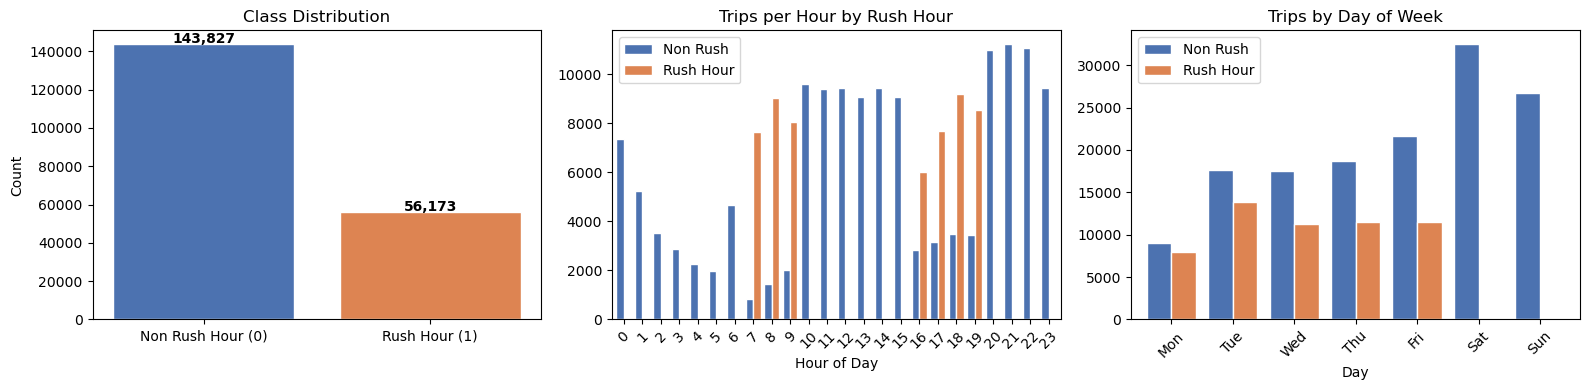

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Class distribution
counts = df['rush_hour'].value_counts()
axes[0].bar(['Non Rush Hour (0)', 'Rush Hour (1)'], counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Plot 2: Hour vs Rush Hour
hour_counts = df.groupby(['pickup_hour', 'rush_hour']).size().unstack(fill_value=0)
hour_counts.plot(kind='bar', ax=axes[1], color=['#4C72B0','#DD8452'],
                 edgecolor='white', width=0.8)
axes[1].set_title('Trips per Hour by Rush Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].legend(['Non Rush', 'Rush Hour'])

# Plot 3: Dayofweek vs Rush Hour
dow_counts = df.groupby(['pickup_dayofweek', 'rush_hour']).size().unstack(fill_value=0)
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_counts.index = [day_names[i] for i in dow_counts.index]
dow_counts.plot(kind='bar', ax=axes[2], color=['#4C72B0','#DD8452'],
                edgecolor='white', width=0.8)
axes[2].set_title('Trips by Day of Week')
axes[2].set_xlabel('Day')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45)
axes[2].legend(['Non Rush', 'Rush Hour'])

plt.tight_layout()
plt.savefig('rush_hour_eda.png', bbox_inches='tight')
plt.show()

Feature engineer

In [5]:
FEATURE_COLS = [
    'pickup_hour', 'pickup_dayofweek',
    'trip_distance', 'trip_duration', 'speed',
    'passenger_count', 'fare_amount', 'total_amount',
]

for col in ['pickup_month', 'is_credit_card']:
    if col in df.columns:
        FEATURE_COLS.append(col)

df_model = df[FEATURE_COLS + ['rush_hour']].dropna()
print(f"Dataset size for modeling: {df_model.shape}")

df_model = df_model.copy()
df_model['is_weekend']  = (df_model['pickup_dayofweek'] >= 5).astype(int)
df_model['fare_per_mile'] = df_model['fare_amount'] / (df_model['trip_distance'] + 1e-6)
df_model['fare_per_min']  = df_model['fare_amount'] / (df_model['trip_duration'] / 60 + 1e-6)

FEATURE_COLS += ['is_weekend', 'fare_per_mile', 'fare_per_min']
print(f"\nFeatures used ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)

Dataset size for modeling: (200000, 11)

Features used (13):
['pickup_hour', 'pickup_dayofweek', 'trip_distance', 'trip_duration', 'speed', 'passenger_count', 'fare_amount', 'total_amount', 'pickup_month', 'is_credit_card', 'is_weekend', 'fare_per_mile', 'fare_per_min']


Train/Test Split & Scaling

In [6]:
X = df_model[FEATURE_COLS]
y = df_model['rush_hour']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Rush hour ratio — Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}")

Train: (160000, 13) | Test: (40000, 13)
Rush hour ratio — Train: 28.09% | Test: 28.09%


Definition models

In [7]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=300, random_state=42), True),
    'Decision Tree':       (DecisionTreeClassifier(max_depth=8, random_state=42), False),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, max_depth=10,
                                                    random_state=42, n_jobs=-1), False),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                                        learning_rate=0.1, random_state=42), False),
    'KNN':                 (KNeighborsClassifier(n_neighbors=11, n_jobs=-1), True),
    'SVM':                 (SVC(kernel='rbf', probability=True, random_state=42), True),
}

models['XGBoost'] = (XGBClassifier(n_estimators=100, max_depth=6,
                                    learning_rate=0.1, random_state=42,
                                    eval_metric='logloss', verbosity=0), False)

print(f"✅ {len(models)} models ready to train")

✅ 7 models ready to train


Training $ Evalution

In [8]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, (model, needs_scaling) in models.items():
    print(f"Training {name}...", end=' ')
    X_tr = X_train_sc if needs_scaling else X_train
    X_te = X_test_sc  if needs_scaling else X_test

    model.fit(X_tr, y_train)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv,
                                 scoring='f1', n_jobs=-1)

    results[name] = {
        'model':     model,
        'scaled':    needs_scaling,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_proba),
        'cv_f1_mean':cv_scores.mean(),
        'cv_f1_std': cv_scores.std(),
        'y_pred':    y_pred,
        'y_proba':   y_proba,
    }
    print(f"F1={results[name]['f1']:.4f} | AUC={results[name]['roc_auc']:.4f}")

print("\n✅ All models trained!")

Training Logistic Regression... F1=0.4395 | AUC=0.8134
Training Decision Tree... F1=1.0000 | AUC=1.0000
Training Random Forest... F1=0.9912 | AUC=1.0000
Training Gradient Boosting... F1=1.0000 | AUC=1.0000
Training KNN... F1=0.8860 | AUC=0.9812
Training SVM... F1=0.7729 | AUC=0.9347
Training XGBoost... F1=1.0000 | AUC=1.0000

✅ All models trained!


In [11]:
# Extract KNN predictions and use as rush_hour column
knn_model = results['KNN']['model']
knn_predictions = knn_model.predict(X_test_sc)

# Create a new dataframe with KNN rush_hour predictions
df_knn_results = X_test.copy()
df_knn_results['rush_hour'] = knn_predictions

print(f"KNN rush_hour predictions added:")
print(df_knn_results[['rush_hour']].value_counts())
print(f"\nShape: {df_knn_results.shape}")
print(df_knn_results.head())

KNN rush_hour predictions added:
rush_hour
0            28645
1            11355
Name: count, dtype: int64

Shape: (40000, 14)
        pickup_hour  pickup_dayofweek  trip_distance  trip_duration  \
57007            21                 3           3.17          840.0   
44201             8                 3           1.90          479.0   
82838            22                 4           1.60          486.0   
131893           21                 4           0.37          158.0   
113806           12                 6           2.82          651.0   

            speed  passenger_count  fare_amount  total_amount  pickup_month  \
57007   13.585714                2         13.0         17.16             3   
44201   14.279749                1          8.5          9.30             3   
82838   11.851852                1          8.0         11.15             3   
131893   8.430380                1          4.0          6.62             3   
113806  15.594470                2         10.5    

## Nhận xét
-   Các model như Decision Tree, Gradient Boosting, XGBoost đạt kết quả perfect (1.0) → có thể:
- Dataset dễ phân tách
- Hoặc có dấu hiệu overfitting
- KNN:
- F1 = 0.886
- AUC = 0.981
- → Không hoàn hảo nhưng ổn định và thực tế hơn

-  Vì vậy chọn KNN để tạo cột rush_hour

In [14]:
def build_features(df):
    df = df.copy()

    # Feature engineering giống lúc train
    df['is_weekend'] = (df['pickup_dayofweek'] >= 5).astype(int)
    df['fare_per_mile'] = df['fare_amount'] / (df['trip_distance'] + 1e-6)
    df['fare_per_min'] = df['fare_amount'] / (df['trip_duration'] / 60 + 1e-6)

    return df

In [16]:
df = build_features(df)

X_full_sc = scaler.transform(df[FEATURE_COLS])

df['rush_hour'] = (knn_model.predict_proba(X_full_sc)[:, 1] > 0.5).astype(int)

df.to_csv("../data/processed/taxi_cleaned_with_rush_hour.csv", index=False)